In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [3]:
df = pd.read_csv("Student_Performance.csv")

df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [4]:
df.shape
df.info()
df.describe()

df.isnull().sum()
df.drop_duplicates(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

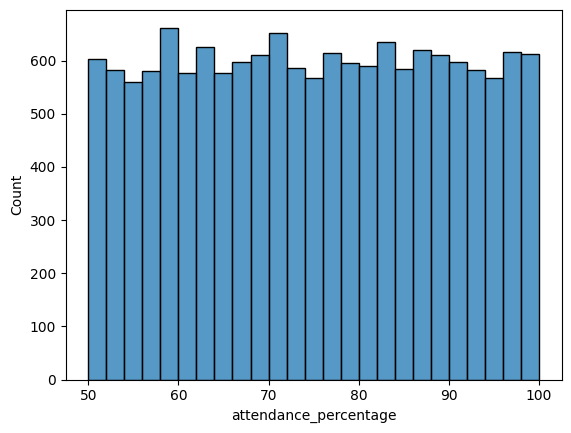

In [5]:
sns.histplot(df['attendance_percentage'])

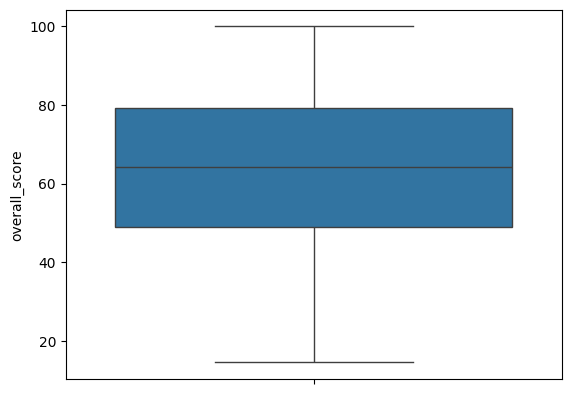

In [6]:
sns.boxplot(df['overall_score'])


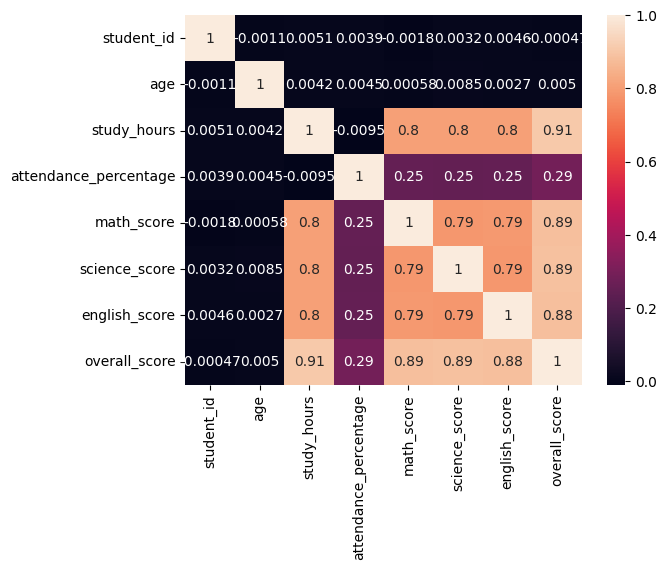

In [7]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [8]:
df["AverageMarks"] = (
    df["math_score"] +
    df["science_score"] +
    df["english_score"]
)/3

In [9]:
df.drop(columns=["parent_education","internet_access","travel_time","final_grade"])

,student_id,age,gender,school_type,study_hours,attendance_percentage,extra_activities,study_method,math_score,science_score,english_score,overall_score,AverageMarks
0,1,14,male,public,3.1,84.3,yes,notes,42.7,55.4,57.0,53.1,51.700000
1,2,18,female,public,3.7,87.8,no,textbook,57.6,68.8,64.8,61.3,63.733333
2,3,17,female,private,7.9,65.5,no,notes,84.8,95.0,79.2,89.6,86.333333
3,4,16,other,public,1.1,58.1,no,notes,44.4,27.5,54.7,41.6,42.200000
4,5,16,female,public,1.3,61.0,yes,group study,8.9,32.7,30.0,25.4,23.866667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,17,male,private,1.8,53.2,no,group study,37.1,37.1,26.8,38.4,33.666667
14996,14997,17,other,private,6.7,63.5,yes,mixed,84.4,67.2,96.2,78.8,82.600000
14997,14998,17,male,private,5.2,58.2,no,group study,69.0,57.2,74.1,64.3,66.766667
14998,14999,16,other,private,1.0,68.7,yes,textbook,24.2,41.4,30.5,33.6,32.033333


In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
X = df[
    [
        "age",
        "study_hours",
        "attendance_percentage",
        "AverageMarks",
        "gender_male",
        "extra_activities_yes"
    ]
]

y = df["overall_score"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42),
}

In [17]:


results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })
best_model = models["Random Forest"]
results_df = pd.DataFrame(results)

print(results_df)

               Model       MAE      RMSE  R² Score
0  Linear Regression  3.302635  4.050066  0.955579
1      Decision Tree  4.649300  5.931005  0.904737
2      Random Forest  3.310685  4.116322  0.954113


In [18]:
def predict_student(age, gender, study_hours,
                    attendance, average_marks,
                    extra_activities):

    gender_male = 1 if gender.lower() == "male" else 0

    extra_activities_yes = (
        1 if extra_activities.lower() == "yes" else 0
    )

    student = pd.DataFrame({
        "age": [age],
        "study_hours": [study_hours],
        "attendance_percentage": [attendance],
        "AverageMarks": [average_marks],
        "gender_male": [gender_male],
        "extra_activities_yes": [extra_activities_yes]
    })

    student = scaler.transform(student)

    prediction = best_model.predict(student)

    return prediction[0]

In [19]:
score = predict_student(
    age=20,
    gender="male",
    study_hours=5,
    attendance=90,
    average_marks=85,
    extra_activities="yes"
)

print(f"Predicted Overall Score: {score:.2f}")

Predicted Overall Score: 81.68


In [20]:
print(X.columns.tolist())

['age', 'study_hours', 'attendance_percentage', 'AverageMarks', 'gender_male', 'extra_activities_yes']


In [21]:
print(best_model.n_features_in_)

6


In [22]:
print(scaler.n_features_in_)

6


In [23]:
print(X.columns.tolist())
print(best_model.n_features_in_)
print(scaler.n_features_in_)

['age', 'study_hours', 'attendance_percentage', 'AverageMarks', 'gender_male', 'extra_activities_yes']
6
6


In [25]:
import joblib




In [26]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [27]:
joblib.dump(best_model, "model.pkl")

['model.pkl']